# **Lab 08:** People Detection in Cloud Vision APIs (*AWS, Azure, Google, NVIDIA*)

This notebook provides a practical **QuickStart** for people detection using cloud vision services from AWS, Azure, Google Cloud, and NVIDIA.

### **Environment and Prerequisites**

You will need:
- A Python 3 environment (e.g., Jupyter, VS Code, or similar).
- Cloud accounts for:
  - AWS (Rekognition).
  - Azure (Azure AI Vision / Image Analysis).
  - Google Cloud (Vision API).
  - NVIDIA (NIM or similar vision microservice, for example a PeopleNet-based endpoint).
- API keys or credentials for each provider.

This notebook assumes you have a local image file named `people.jpg` in the same directory as the notebook. You can replace it with any image path you prefer.

In [ ]:
%pip install azure-ai-vision-imageanalysis azure-core
%pip install google-cloud-vision
%pip install boto3
%pip install requests

## **AWS Rekognition** – Person Detection via DetectLabels

![](aws_rekognition.png)

[AWS Rekognition](https://aws.amazon.com/pm/rekognition/?trk=6f58ae4e-0833-45f9-a21c-424b56761d19&sc_channel=ps&ef_id=CjwKCAjwnZfPBhAGEiwAzg-VzLT1PXUihhIuB8yZ-OIG4AW4O_IVmC6ET75JN54FjUcFytubvU-92hoCQOIQAvD_BwE:G:s&s_kwcid=AL!4422!3!798628455734!p!!g!!amazon%20image%20analysis!23600694654!193803764356&gad_campaignid=23600694654&gbraid=0AAAAADjHtp9YXOk8icgBSpUNHeUCp0rT-&gclid=CjwKCAjwnZfPBhAGEiwAzg-VzLT1PXUihhIuB8yZ-OIG4AW4O_IVmC6ET75JN54FjUcFytubvU-92hoCQOIQAvD_BwE) provides the `DetectLabels` API, which can detect the label "Person" and return bounding boxes for instances of that label in an image.

### AWS Setup

You need:
- An AWS account.
- IAM credentials with permissions to use Rekognition.
- AWS credentials configured via environment variables, AWS CLI, or configuration files.

The code below assumes your AWS credentials are already configured in your environment.

In [ ]:
import boto3
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# -----------------------------
# 1. AWS CREDENTIALS (NO SETUP REQUIRED)
# -----------------------------
AWS_ACCESS_KEY_ID = "<YOUR_AWS_ACCESS_KEY_ID>"
AWS_SECRET_ACCESS_KEY = "<YOUR_AWS_SECRET_ACCESS_KEY>"
AWS_REGION = "us-east-1"   # Cambia si usas otra región

rek_client = boto3.client(
    "rekognition",
    aws_access_key_id=AWS_ACCESS_KEY_ID,
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    region_name=AWS_REGION
)

# -----------------------------
# 2. LOAD IMAGE
# -----------------------------
image_path = "people.jpg"
image = Image.open(image_path)
img_w, img_h = image.size

with open(image_path, "rb") as f:
    image_bytes = f.read()

# -----------------------------
# 3. CALL AWS REKOGNITION
# -----------------------------
response = rek_client.detect_labels(
    Image={"Bytes": image_bytes},
    MaxLabels=50,
    MinConfidence=50.0
)

/Users/eugenio/Documents/Computer_Vision/.venv/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


AWS Rekognition detected 41 people


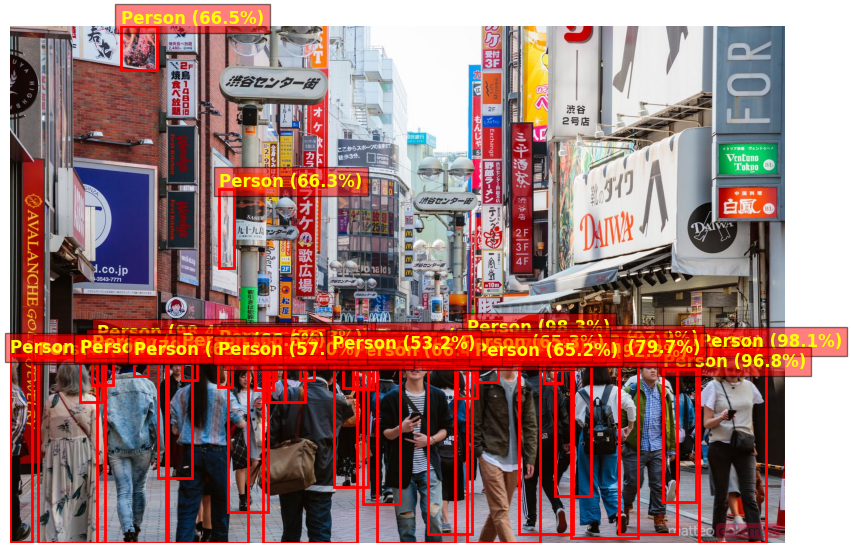

In [ ]:
# -----------------------------
# 4. EXTRACT PERSON DETECTIONS
# -----------------------------
persons = []
for label in response["Labels"]:
    if label["Name"].lower() == "person":
        for instance in label.get("Instances", []):
            bbox = instance["BoundingBox"]  # normalized
            persons.append({
                "confidence": instance.get("Confidence", label["Confidence"]),
                "bbox": [
                    bbox["Left"],
                    bbox["Top"],
                    bbox["Width"],
                    bbox["Height"]
                ]
            })

print("AWS Rekognition detected", len(persons), "people")

# -----------------------------
# 5. DRAW BOUNDING BOXES
# -----------------------------
fig, ax = plt.subplots(1, figsize=(10, 10))
ax.imshow(image)

for p in persons:
    left, top, width, height = p["bbox"]

    # Convert normalized → absolute pixel coords
    x1 = left * img_w
    y1 = top * img_h
    w = width * img_w
    h = height * img_h

    # Draw rectangle
    rect = patches.Rectangle(
        (x1, y1), w, h,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

    # Draw label text
    label = f"Person ({p['confidence']:.1f}%)"
    ax.text(
        x1, y1 - 5,
        label,
        color="yellow",
        fontsize=12,
        weight="bold",
        bbox=dict(facecolor="red", alpha=0.5)
    )

plt.axis("off")
plt.show()

### AWS Free Tier Notes

- AWS Rekognition offers a free tier of approximately 5,000 images per month for the first 12 months after you create your AWS account.
- After the first 12 months, all Rekognition usage is billed according to standard pricing.
- There is no perpetual free tier for people detection.
- This makes AWS Rekognition suitable for short-term experimentation and early-stage courses, but not for long-term free use beyond the first year.

## 1. Azure AI Vision – People Detection (Preview)

[Azure AI Vision](https://azure.microsoft.com/en-us/products/ai-foundry/tools/vision) (Image Analysis) provides a People Detection feature (currently in preview) that returns bounding boxes and confidence scores for people in an image.

### 1.1. Azure Setup

You need:
- An Azure subscription.
- An Azure AI Vision (Image Analysis) resource.
- The endpoint URL and API key.

Replace `<your-resource-name>` and `<your-key>` below with your actual values.

In [ ]:
from azure.ai.vision.imageanalysis import ImageAnalysisClient
from azure.core.credentials import AzureKeyCredential

AZURE_ENDPOINT = "https://<your-resource-name>.cognitiveservices.azure.com/"  # TODO: replace
AZURE_KEY = "<your-key>"  # TODO: replace

azure_client = ImageAnalysisClient(endpoint=AZURE_ENDPOINT, credential=AzureKeyCredential(AZURE_KEY))

In [ ]:
image_path = "people.jpg"  # You can change this path

with open(image_path, "rb") as f:
    image_data = f.read()

azure_result = azure_client.analyze(
    image_data=image_data,
    features=["People"]
)

azure_people = []
for person in azure_result.people:
    bbox = person.bounding_box  # typically x, y, width, height
    azure_people.append({
        "confidence": float(person.confidence),
        "bbox": [float(bbox.x), float(bbox.y), float(bbox.w), float(bbox.h)]
    })

print("Azure detected", len(azure_people), "people")
for p in azure_people:
    print(p)

### 1.2. Azure Free Tier Notes

- Approximately 5,000 free transactions per month on the F0 (free) tier for Image Analysis.
- Rate limit around 20 transactions per minute on the free tier.
- People Detection is a preview feature but included in the Image Analysis free tier.
- After the free quota, pricing is typically on the order of 1 USD per 1,000 transactions (exact pricing may vary by region and time).
- This makes Azure suitable for continuous classroom use and ongoing proof-of-concept projects, as the free tier renews monthly.

## 2. Google Cloud Vision – Object Localization (People as "person" Label)

Google Cloud Vision does not provide a dedicated people detection API, but its Object Localization feature can detect objects labeled as "Person" and return bounding boxes.

### 2.1. Google Cloud Setup

You need:
- A Google Cloud project with the Vision API enabled.
- Service account credentials (JSON key file) or application default credentials.

Set the environment variable `GOOGLE_APPLICATION_CREDENTIALS` to point to your JSON key file, or configure credentials using the Google Cloud SDK.

In [ ]:
from google.cloud import vision

gcv_client = vision.ImageAnnotatorClient()

with open(image_path, "rb") as f:
    content = f.read()

gcv_image = vision.Image(content=content)
gcv_response = gcv_client.object_localization(image=gcv_image)
gcv_objects = gcv_response.localized_object_annotations

gcv_people = []
for obj in gcv_objects:
    if obj.name.lower() == "person":
        # bounding_poly is normalized [0,1]; we keep it as is for evaluation
        vertices = [(v.x, v.y) for v in obj.bounding_poly.normalized_vertices]
        gcv_people.append({
            "score": float(obj.score),
            "bbox_normalized": vertices
        })

print("Google Cloud Vision detected", len(gcv_people), "people")
for p in gcv_people:
    print(p)

### 2.2. Google Cloud Free Tier Notes

- Google Cloud Vision does not provide a recurring free monthly quota specifically for object detection or object localization.
- New users typically receive a 300 USD credit valid for 90 days.
- After the trial period, all Vision API usage is billed according to standard pricing.
- This makes Google Cloud Vision suitable for short-term experimentation and courses, but not for long-term free proof-of-concept deployments.

## 4. NVIDIA – People Detection via NIM (PeopleNet or Similar Models)

NVIDIA provides vision models such as PeopleNet through its inference microservices (NIM) and the NVIDIA API catalog. These services expose REST or gRPC endpoints for object detection, including people.

The exact endpoint and authentication mechanism depend on how you deploy or subscribe to the NVIDIA service (for example, via NVIDIA NGC, NVIDIA AI Enterprise, or a cloud marketplace). The example below assumes a generic REST endpoint for a people detection model.

### 4.1. NVIDIA Setup

You need:
- Access to a deployed NVIDIA NIM or similar inference service that exposes a people detection model (for example, PeopleNet).
- An endpoint URL and an API key or token.

Replace `<your-nim-endpoint>` and `<your-api-key>` with your actual values. The request format may vary depending on the specific deployment; consult the NVIDIA documentation for your service.

In [ ]:
import requests
import json

NVIDIA_ENDPOINT = "https://<your-nim-endpoint>/v1/vision/detect"  # TODO: replace
NVIDIA_API_KEY = "<your-api-key>"  # TODO: replace

headers = {
    "Authorization": f"Bearer {NVIDIA_API_KEY}"
}

with open(image_path, "rb") as f:
    img_bytes = f.read()

nv_response = requests.post(
    NVIDIA_ENDPOINT,
    headers=headers,
    files={"image": ("people.jpg", img_bytes, "image/jpeg")}
)

if nv_response.status_code != 200:
    print("NVIDIA request failed with status", nv_response.status_code)
    print(nv_response.text)
    nv_people = []
else:
    nv_data = nv_response.json()
    # The exact response schema depends on the deployed model.
    # Here we assume a generic format: a list of detections with class, confidence, and bbox.
    nv_people = []
    for det in nv_data.get("detections", []):
        if det.get("class", "").lower() in ["person", "people"]:
            bbox = det.get("bbox", [])  # e.g., [x, y, w, h] or normalized
            nv_people.append({
                "confidence": float(det.get("confidence", 0.0)),
                "bbox": bbox
            })

    print("NVIDIA service detected", len(nv_people), "people")
    for p in nv_people:
        print(p)

### 4.2. NVIDIA Free Tier Notes

- NVIDIA provides access to models via the NVIDIA API catalog and NIM, often with limited free trial usage or credits.
- There is no widely advertised perpetual free tier for hosted people detection services comparable to Azure's recurring free transactions.
- However, many NVIDIA models (such as PeopleNet) can be run locally or on your own GPU infrastructure using containers from NVIDIA NGC, which can be cost-effective for research and teaching if you already have GPU resources.
- For cloud-hosted inference, expect usage-based billing after any initial trial or promotional credits.

## 5. Suggested Dataset for Classroom Use

For teaching and experimentation, you can use:
- A small subset of the COCO dataset containing images with people.
- A custom dataset of campus or classroom images, collected with appropriate consent and privacy considerations.

For simplicity, this notebook assumes a folder structure like:

```text
data/
  images/
    img_001.jpg
    img_002.jpg
    ...
  annotations/
    img_001.json
    img_002.json
    ...
```

Where each `img_xxx.json` file contains ground truth bounding boxes for people in a simple format, for example:

```json
{
  "image": "img_001.jpg",
  "width": 1920,
  "height": 1080,
  "people": [
    {"bbox": [x, y, w, h]},
    {"bbox": [x, y, w, h]}
  ]
}
```

## 6. Automatic Evaluation Utilities

The following cells provide simple utilities to evaluate people detection results using Intersection over Union (IoU) and basic recall metrics.

Assumptions:
- Ground truth bounding boxes are in absolute pixel coordinates `[x, y, w, h]`.
- Predicted bounding boxes may be in absolute or normalized coordinates; you must convert them to absolute coordinates before evaluation.
- The evaluation here is intentionally simple and suitable for teaching purposes, not for rigorous benchmarking.

In [ ]:
import os
import json
from typing import List, Dict

def iou(box_a, box_b):
    """Compute Intersection over Union (IoU) between two boxes [x, y, w, h]."""
    ax, ay, aw, ah = box_a
    bx, by, bw, bh = box_b

    ax2, ay2 = ax + aw, ay + ah
    bx2, by2 = bx + bw, by + bh

    inter_x1 = max(ax, bx)
    inter_y1 = max(ay, by)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = aw * ah
    area_b = bw * bh
    union_area = area_a + area_b - inter_area

    if union_area <= 0:
        return 0.0
    return inter_area / union_area

def match_detections_to_gt(gt_boxes: List[List[float]], pred_boxes: List[List[float]], iou_threshold: float = 0.5):
    """Match predicted boxes to ground truth boxes using a greedy IoU-based strategy."""
    matched_gt = set()
    matched_pred = set()

    for i, p in enumerate(pred_boxes):
        best_iou = 0.0
        best_j = None
        for j, g in enumerate(gt_boxes):
            if j in matched_gt:
                continue
            score = iou(p, g)
            if score > best_iou:
                best_iou = score
                best_j = j
        if best_j is not None and best_iou >= iou_threshold:
            matched_pred.add(i)
            matched_gt.add(best_j)

    tp = len(matched_gt)
    fp = len(pred_boxes) - len(matched_pred)
    fn = len(gt_boxes) - len(matched_gt)
    return tp, fp, fn

def evaluate_dataset(gt_dir: str, pred_dir: str, iou_threshold: float = 0.5):
    """Evaluate a dataset given ground truth and prediction JSON files.

    Ground truth format (per image):
    {
      "image": "img_001.jpg",
      "width": 1920,
      "height": 1080,
      "people": [
        {"bbox": [x, y, w, h]},
        ...
      ]
    }

    Prediction format (per image):
    {
      "image": "img_001.jpg",
      "people": [
        {"bbox": [x, y, w, h], "confidence": 0.9},
        ...
      ]
    }
    """
    total_tp = 0
    total_fp = 0
    total_fn = 0

    for fname in os.listdir(gt_dir):
        if not fname.endswith(".json"):
            continue
        gt_path = os.path.join(gt_dir, fname)
        pred_path = os.path.join(pred_dir, fname)
        if not os.path.exists(pred_path):
            continue

        with open(gt_path, "r") as f:
            gt_data = json.load(f)
        with open(pred_path, "r") as f:
            pred_data = json.load(f)

        gt_boxes = [p["bbox"] for p in gt_data.get("people", [])]
        pred_boxes = [p["bbox"] for p in pred_data.get("people", [])]

        tp, fp, fn = match_detections_to_gt(gt_boxes, pred_boxes, iou_threshold=iou_threshold)
        total_tp += tp
        total_fp += fp
        total_fn += fn

    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0

    return {
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
        "precision": precision,
        "recall": recall
    }

### 6.1. Example: Evaluating a Single Provider

Assume you have generated prediction JSON files for one provider (for example, Azure) and stored them in a directory `predictions_azure/`, with the same filenames as the ground truth JSON files in `data/annotations/`.

You can then run the following cell to compute simple precision and recall metrics.

In [ ]:
# Example usage (adjust paths as needed):
gt_dir = "data/annotations"        # TODO: replace with your ground truth directory
pred_dir = "predictions_azure"     # TODO: replace with your predictions directory

if os.path.exists(gt_dir) and os.path.exists(pred_dir):
    metrics = evaluate_dataset(gt_dir, pred_dir, iou_threshold=0.5)
    print("Evaluation metrics for Azure predictions:")
    print(metrics)
else:
    print("Ground truth or prediction directory does not exist. Please configure paths and files.")

## 7. Student Exercises

The following exercises are intended for students in a Computer Vision in the Cloud course.

1. **API Integration Exercise**
   - Configure credentials for Azure, Google Cloud, AWS, and NVIDIA.
   - Run the people detection examples on at least 5 different images.
   - Save the predictions for each provider in separate directories (for example, `predictions_azure/`, `predictions_gcv/`, `predictions_aws/`, `predictions_nv/`).

2. **Evaluation Exercise**
   - Create ground truth annotation JSON files for your images following the format described in Section 5.
   - Use the evaluation utilities in Section 6 to compute precision and recall for each provider.
   - Compare the results and discuss which provider performs best on your dataset.

3. **Cost and Free-Tier Analysis**
   - Using the official pricing pages, estimate the monthly cost of running 100,000 people detection requests for each provider.
   - Identify which provider is most suitable for:
     - A university course with many students.
     - A small startup building a proof-of-concept.
   - Consider both free-tier limitations and long-term pricing.

4. **Robustness and Fairness Discussion**
   - Collect images with diverse lighting conditions, camera angles, and crowd densities.
   - Evaluate how each provider performs under these conditions.
   - Discuss potential fairness and bias issues in people detection models and how they might impact real-world applications.

5. **Extension Exercise (Optional)**
   - Extend the evaluation utilities to compute additional metrics such as F1-score or average precision.
   - Implement a simple visualization that overlays predicted and ground truth bounding boxes on the images for qualitative analysis.

## 8. Free-Tier and Long-Term Usability Summary

| Provider | People Detection Mechanism | Free Monthly Quota | Duration | Long-Term Free Use |
|---------|----------------------------|--------------------|----------|---------------------|
| Azure | Image Analysis – People Detection (preview) | Approximately 5,000 transactions/month (F0 tier) | Indefinite (as long as F0 is offered) | Yes, suitable for ongoing teaching and proof-of-concept work |
| Google Cloud | Vision Object Localization ("Person" label) | No recurring free quota; 300 USD credit | 90 days | No recurring free tier for detection |
| AWS | Rekognition DetectLabels ("Person") | Approximately 5,000 images/month | First 12 months only | No perpetual free tier |
| NVIDIA | NIM / PeopleNet or similar models | Trial or promotional credits; local GPU possible | Varies by program | No widely advertised perpetual free hosted tier; local deployment possible |

For a university course and early-stage proof-of-concept work, Azure's recurring free tier is generally the most convenient option. Google Cloud and AWS are well-suited for short-term experiments and trials, while NVIDIA is attractive when you have access to GPU resources and want to run models locally or in a custom deployment.

---

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>